# Station Distance Frequency Diagram

This notebook creates a thesis-ready frequency diagram showing the distance from each observation station to the nearest SNOWPACK virtual station used in the observation validation.

The distance values are taken from `data/processed/observation_validation_three_models.csv`, because this file is produced by the observation-validation workflow and contains the actual nearest-SNOWPACK matches.


## 1. Imports and Paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures_thesis"
FIGURES.mkdir(exist_ok=True)

RESULTS_PATH = PROCESSED / "observation_validation_three_models.csv"
STATS_PATH = PROCESSED / "station_distance_statistics.csv"
FREQUENCY_TABLE_PATH = PROCESSED / "station_distance_frequency_table.csv"
FIGURE_PNG = FIGURES / "13_station_distance_frequency.png"
FIGURE_PDF = FIGURES / "13_station_distance_frequency.pdf"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})


Matplotlib is building the font cache; this may take a moment.


## 2. Load Distance Data

In [2]:
required_cols = ["Station", "Station_Code", "SNOWPACK_Station", "SNOWPACK_Distance_m"]

if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"Missing input file: {RESULTS_PATH}")

stations = pd.read_csv(RESULTS_PATH)
missing_cols = [col for col in required_cols if col not in stations.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in {RESULTS_PATH.name}: {missing_cols}")

stations = stations.copy()
stations["SNOWPACK_Distance_m"] = pd.to_numeric(stations["SNOWPACK_Distance_m"], errors="coerce")
stations = stations.dropna(subset=["SNOWPACK_Distance_m"]).copy()
stations["SNOWPACK_Distance_km"] = stations["SNOWPACK_Distance_m"] / 1000

if stations.empty:
    raise ValueError("No valid SNOWPACK distances found.")

print(f"Loaded {len(stations)} stations from {RESULTS_PATH.relative_to(ROOT)}")
stations[required_cols + ["SNOWPACK_Distance_km"]].sort_values("SNOWPACK_Distance_m")


Loaded 11 stations from data/processed/observation_validation_three_models.csv


,Station,Station_Code,SNOWPACK_Station,SNOWPACK_Distance_m,SNOWPACK_Distance_km
9,Sognefjellhytta,SN55290,VIR1584A,196.294904,0.196295
5,Grotli Iii,SN15890,VIR2420A,244.296784,0.244297
8,Fv53 Tyinosen,SN54815,VIR4717A,3387.707962,3.387708
3,Bøverdal,SN15430,VIR1635A,4154.695082,4.154695
1,Fv51 Valdresflye,SN13760,VIR4720A,5637.929232,5.637929
7,Filefjell - Kyrkjestølane,SN54710,VIR4714A,5823.733764,5.823734
4,Skjåk,SN15660,VIR1635A,7457.688509,7.457689
6,Beitostølen Ii,SN23550,VIR4120A,7899.528792,7.899529
0,Øvre Heimdalsvatn,SN13750,VIR3243A,9688.586329,9.688586
2,Juvvasshøe,SN15270,VIR8A,11718.072201,11.718072


## 3. Summary Statistics

In [3]:
dist_km = stations["SNOWPACK_Distance_km"]

stats_df = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean distance (km)",
        "Median distance (km)",
        "Std. deviation (km)",
        "Minimum distance (km)",
        "Maximum distance (km)",
        "25th percentile (km)",
        "75th percentile (km)",
        "90th percentile (km)",
        "Stations within 5 km (%)",
        "Stations within 10 km (%)",
    ],
    "Value": [
        len(dist_km),
        dist_km.mean(),
        dist_km.median(),
        dist_km.std(ddof=1),
        dist_km.min(),
        dist_km.max(),
        dist_km.quantile(0.25),
        dist_km.quantile(0.75),
        dist_km.quantile(0.90),
        100 * (dist_km <= 5).mean(),
        100 * (dist_km <= 10).mean(),
    ],
})

stats_df.to_csv(STATS_PATH, index=False)
print(f"Saved statistics to {STATS_PATH.relative_to(ROOT)}")
stats_df


Saved statistics to data/processed/station_distance_statistics.csv


,Statistic,Value
0,Count,11.000000
1,Mean distance (km),7.544038
2,Median distance (km),5.823734
3,Std. deviation (km),7.311979
4,Minimum distance (km),0.196295
5,Maximum distance (km),26.775883
6,25th percentile (km),3.771202
7,75th percentile (km),8.794058
8,90th percentile (km),11.718072
9,Stations within 5 km (%),36.363636


## 4. Frequency Diagram

Saved figure to figures_thesis/13_station_distance_frequency.png
Saved figure to figures_thesis/13_station_distance_frequency.pdf


,Distance class (km),Station count,Percentage
0,0-5,4,36.363636
1,5-10,5,45.454545
2,10-15,1,9.090909
3,15-20,0,0.000000
4,20-25,0,0.000000
5,25-30,1,9.090909


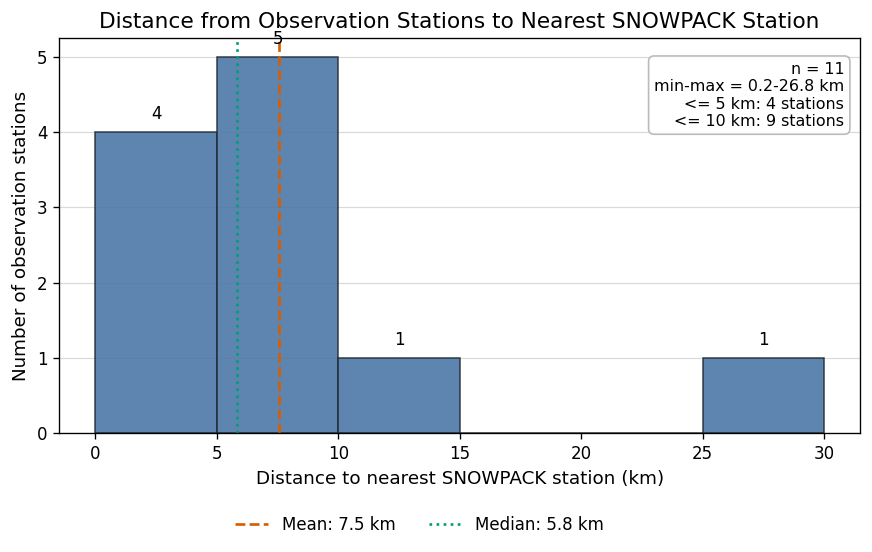

In [4]:
bin_width_km = 5
max_edge = np.ceil(dist_km.max() / bin_width_km) * bin_width_km
bin_edges = np.arange(0, max_edge + bin_width_km, bin_width_km)

if len(bin_edges) < 3:
    bin_edges = np.array([0, bin_width_km, 2 * bin_width_km])

labels = [f"{int(left)}-{int(right)}" for left, right in zip(bin_edges[:-1], bin_edges[1:])]
frequency = pd.cut(dist_km, bins=bin_edges, right=False, include_lowest=True, labels=labels)
frequency_table = frequency.value_counts(sort=False).rename_axis("Distance class (km)").reset_index(name="Station count")
frequency_table["Percentage"] = 100 * frequency_table["Station count"] / len(dist_km)
frequency_table.to_csv(FREQUENCY_TABLE_PATH, index=False)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
counts, bins, patches = ax.hist(
    dist_km,
    bins=bin_edges,
    color="#4C78A8",
    edgecolor="#1F2933",
    linewidth=0.9,
    alpha=0.9,
)

for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        ax.text((left + right) / 2, count + 0.12, f"{int(count)}", ha="center", va="bottom", fontsize=10)

ax.axvline(dist_km.mean(), color="#D55E00", linewidth=1.6, linestyle="--", label=f"Mean: {dist_km.mean():.1f} km")
ax.axvline(dist_km.median(), color="#009E73", linewidth=1.6, linestyle=":", label=f"Median: {dist_km.median():.1f} km")

stats_text = (
    f"n = {len(dist_km)}\n"
    f"min-max = {dist_km.min():.1f}-{dist_km.max():.1f} km\n"
    f"<= 5 km: {(dist_km <= 5).sum()} stations\n"
    f"<= 10 km: {(dist_km <= 10).sum()} stations"
)
ax.text(
    0.98, 0.94, stats_text, transform=ax.transAxes, ha="right", va="top", fontsize=9.5,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#B8B8B8", "alpha": 0.95},
)

ax.set_title("Distance from Observation Stations to Nearest SNOWPACK Station")
ax.set_xlabel("Distance to nearest SNOWPACK station (km)")
ax.set_ylabel("Number of observation stations")
ax.set_xticks(bin_edges)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", color="#D0D0D0", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.45, -0.17), ncol=2, frameon=False)

fig.tight_layout()
fig.savefig(FIGURE_PNG, bbox_inches="tight")
fig.savefig(FIGURE_PDF, bbox_inches="tight")
print(f"Saved figure to {FIGURE_PNG.relative_to(ROOT)}")
print(f"Saved figure to {FIGURE_PDF.relative_to(ROOT)}")

frequency_table


## 5. Sorted Station Distances

In [5]:
station_distance_table = (
    stations[["Station", "Station_Code", "SNOWPACK_Station", "SNOWPACK_Distance_km"]]
    .sort_values("SNOWPACK_Distance_km")
    .reset_index(drop=True)
)
station_distance_table["SNOWPACK_Distance_km"] = station_distance_table["SNOWPACK_Distance_km"].round(2)
station_distance_table


,Station,Station_Code,SNOWPACK_Station,SNOWPACK_Distance_km
0,Sognefjellhytta,SN55290,VIR1584A,0.20
1,Grotli Iii,SN15890,VIR2420A,0.24
2,Fv53 Tyinosen,SN54815,VIR4717A,3.39
3,Bøverdal,SN15430,VIR1635A,4.15
4,Fv51 Valdresflye,SN13760,VIR4720A,5.64
5,Filefjell - Kyrkjestølane,SN54710,VIR4714A,5.82
6,Skjåk,SN15660,VIR1635A,7.46
7,Beitostølen Ii,SN23550,VIR4120A,7.90
8,Øvre Heimdalsvatn,SN13750,VIR3243A,9.69
9,Juvvasshøe,SN15270,VIR8A,11.72


## 6. Suggested Thesis Text

In [6]:
methods_text = f"""The distance between each observation station and the nearest SNOWPACK virtual station was calculated to assess the spatial representativeness of the point-based model validation. The {len(dist_km)} observation stations were located {dist_km.min():.1f}-{dist_km.max():.1f} km from their nearest SNOWPACK virtual station, with a mean distance of {dist_km.mean():.1f} km and a median distance of {dist_km.median():.1f} km. {(dist_km <= 10).sum()} of the {len(dist_km)} stations were within 10 km of a SNOWPACK virtual station."""

print(methods_text)


The distance between each observation station and the nearest SNOWPACK virtual station was calculated to assess the spatial representativeness of the point-based model validation. The 11 observation stations were located 0.2-26.8 km from their nearest SNOWPACK virtual station, with a mean distance of 7.5 km and a median distance of 5.8 km. 9 of the 11 stations were within 10 km of a SNOWPACK virtual station.
